In [7]:
import pandas as pd

# loading the data
df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
df.info()  # 10,0000 entries
df.columns 

 # 0   UDI                      10000 non-null  int64  
 # 1   Product ID               10000 non-null  object 
 # 2   Type                     10000 non-null  object 
 # 3   Air temperature [K]      10000 non-null  float64
 # 4   Process temperature [K]  10000 non-null  float64
 # 5   Rotational speed [rpm]   10000 non-null  int64  
 # 6   Torque [Nm]              10000 non-null  float64
 # 7   Tool wear [min]          10000 non-null  int64  
 # 8   Machine failure          10000 non-null  int64  
 # 9   TWF                      10000 non-null  int64  
 # 10  HDF                      10000 non-null  int64  
 # 11  PWF                      10000 non-null  int64  
 # 12  OSF                      10000 non-null  int64  
 # 13  RNF                      10000 non-null  int64  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [9]:


df["Machine failure"].value_counts() # 9661 pass ; 339 fail




Machine failure
0    9661
1     339
Name: count, dtype: int64

In [10]:
# to check the balance of the dataset
df["Machine failure"].value_counts(normalize=True) * 100


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [11]:

df.describe()



,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [12]:
df["Type"].value_counts()
#product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [13]:
# declare the features
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features] # sensor inputs 
y = df["Machine failure"] # machine failure labels

print(X.shape)
print(y.shape)


(10000, 5)
(10000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y #makes the trainign and testing sets both hav about the same failure percentage


In [15]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 5)
X_test: (2000, 5)
y_train: (8000,)
y_test: (2000,)


In [16]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Testing target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [17]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix


dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(confusion_matrix(y_test, dummy_pred))
print(classification_report(y_test, dummy_pred))





[[1932    0]
 [  68    0]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42, #arbitrary randomness value
    class_weight="balanced" #mistakes on the rare class of failing should count more
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))



[[1927    5]
 [  29   39]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [19]:
# trying different threshold probabiliotes to catch more failures

rf_probs = rf.predict_proba(X_test)[:, 1]

rf_probs[:10]




array([0.14, 0.  , 0.08, 0.  , 0.04, 0.  , 0.  , 0.  , 0.  , 0.  ])

## Threshold Optimization

The default classification threshold is 0.50, meaning the model predicts machine failure only when the predicted failure probability is at least 50%. Since machine failures are rare in this dataset, this threshold may miss too many actual failures.

Because missed failures are more costly than false alarms in predictive maintenance, I evaluated multiple thresholds and selected the threshold that maximized the F2 score. F2 gives more weight to recall than precision, making it useful when catching failures is the priority.

In [20]:
# tetsing out multiple threshold levels

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

for threshold in thresholds:
    print(f"\nThreshold: {threshold}")

    preds = (rf_probs >= threshold).astype(int)

    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))






Threshold: 0.5
[[1927    5]
 [  29   39]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000


Threshold: 0.4
[[1925    7]
 [  24   44]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.65      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000


Threshold: 0.3
[[1916   16]
 [  17   51]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.75      0.76        68

    accuracy                           0.98      2000

In [24]:
# F2 cares more about recall; gives more weight to the failures; would expect to use F2

from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score
import numpy as np

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:
    preds = (rf_probs >= threshold).astype(int)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division = 0)
    f1 = f1_score(y_test, preds, zero_division = 0)
    f2 = fbeta_score(y_test, preds, beta=2, zero_division = 0)


    results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2
    })



# turn the thresholds and their scores into a table
results_df = pd.DataFrame(results)
results_df.head()

# finding the best f2 score
best_f2_row = results_df.loc[results_df["f2"].idxmax()]
best_f2_row


best_threshold = best_f2_row["threshold"]

best_preds = (rf_probs >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print(confusion_matrix(y_test, best_preds))
print(classification_report(y_test, best_preds))


Best threshold: 0.33
[[1922   10]
 [  17   51]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.84      0.75      0.79        68

    accuracy                           0.99      2000
   macro avg       0.91      0.87      0.89      2000
weighted avg       0.99      0.99      0.99      2000



Because the dataset was highly imbalanced and missed failures are costly in predictive maintenance, I optimized the classification threshold using F2 score, which weights recall more heavily than precision.

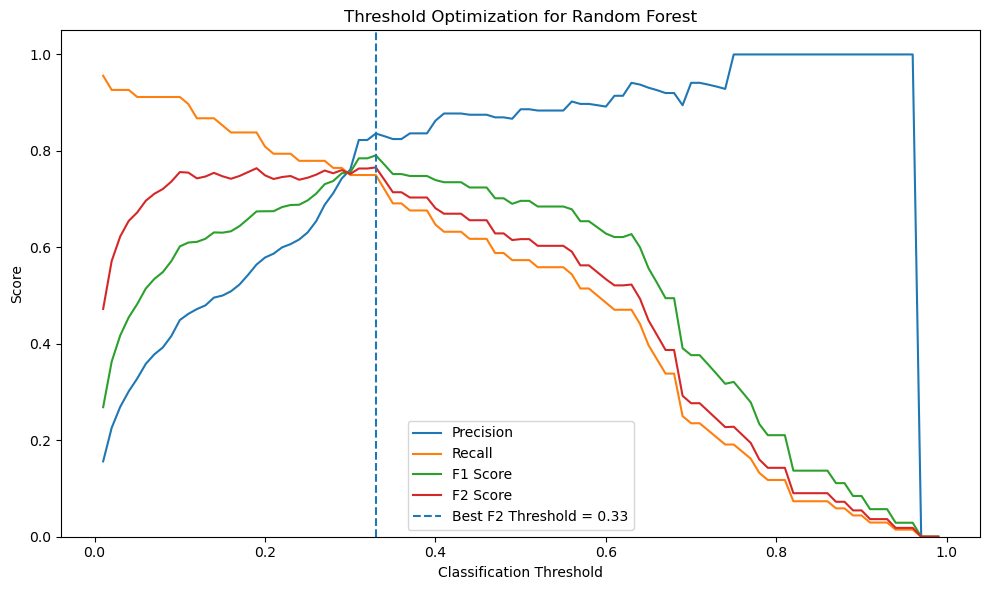

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.plot(results_df["threshold"], results_df["f2"], label="F2 Score")

plt.axvline(best_threshold, linestyle="--", label=f"Best F2 Threshold = {best_threshold:.2f}")

plt.title("Threshold Optimization for Random Forest")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


plt.savefig("../visuals/threshold_optimization_for_random_forest.png", dpi=300, bbox_inches="tight")

In [ ]:
best_threshold = best_f2_row["threshold"]

best_preds = (rf_probs >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print(confusion_matrix(y_test, best_preds))
print(classification_report(y_test, best_preds))

In [28]:



default_threshold = 0.50
optimized_threshold = best_threshold

default_preds = (rf_probs >= default_threshold).astype(int)
optimized_preds = (rf_probs >= optimized_threshold).astype(int)





In [29]:
#making a comparison table


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

comparison = pd.DataFrame({
    "Model": ["Random Forest Default Threshold", "Random Forest Optimized Threshold"],
    "Threshold": [default_threshold, optimized_threshold],
    "Accuracy": [
        accuracy_score(y_test, default_preds),
        accuracy_score(y_test, optimized_preds)
    ],
    "Precision": [
        precision_score(y_test, default_preds),
        precision_score(y_test, optimized_preds)
    ],
    "Recall": [
        recall_score(y_test, default_preds),
        recall_score(y_test, optimized_preds)
    ],
    "F1 Score": [
        f1_score(y_test, default_preds),
        f1_score(y_test, optimized_preds)
    ],
    "F2 Score": [
        fbeta_score(y_test, default_preds, beta=2),
        fbeta_score(y_test, optimized_preds, beta=2)
    ]
})

comparison

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Random Forest Default Threshold,0.50,0.9830,0.886364,0.573529,0.696429,0.617089
1,Random Forest Optimized Threshold,0.33,0.9865,0.836066,0.750000,0.790698,0.765766


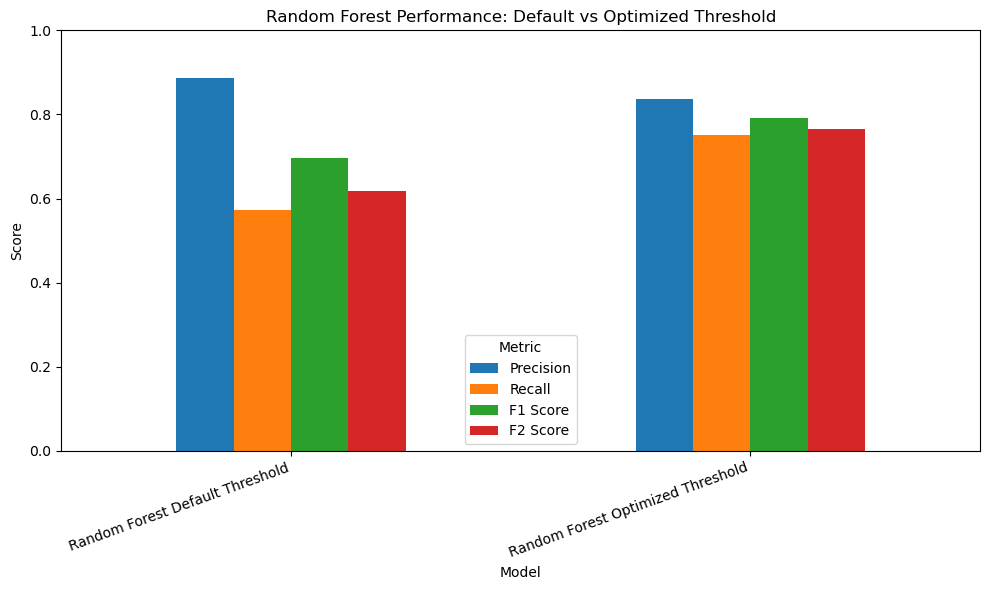

In [30]:
# using an ugly bar chart to visulaize the differences
import matplotlib.pyplot as plt

metrics_to_plot = ["Precision", "Recall", "F1 Score", "F2 Score"]

comparison_plot = comparison.set_index("Model")[metrics_to_plot]

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Random Forest Performance: Default vs Optimized Threshold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

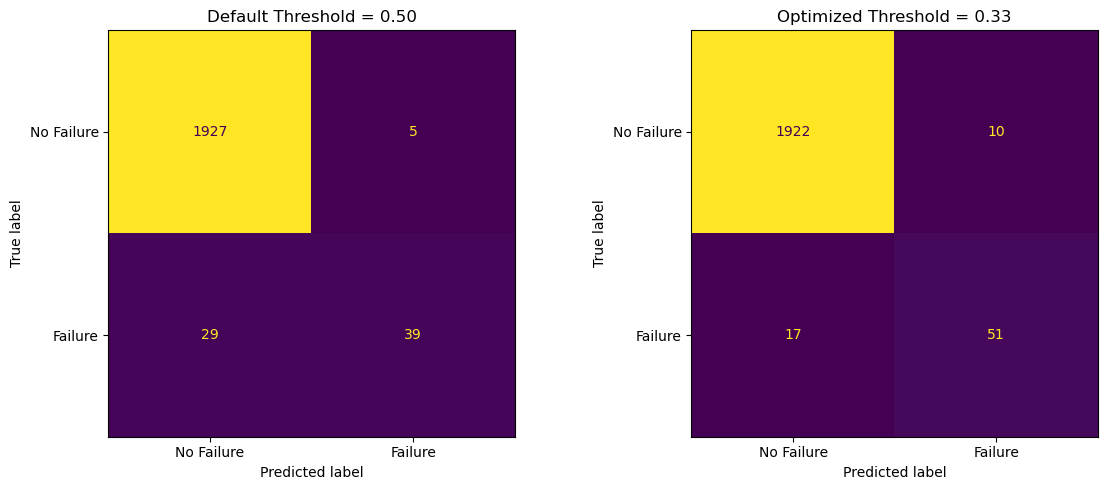

<Figure size 640x480 with 0 Axes>

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    default_preds,
    display_labels=["No Failure", "Failure"],
    ax=axes[0],
    colorbar=False
)

axes[0].set_title("Default Threshold = 0.50")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_preds,
    display_labels=["No Failure", "Failure"],
    ax=axes[1],
    colorbar=False
)

axes[1].set_title(f"Optimized Threshold = {best_threshold:.2f}")

plt.tight_layout()
plt.show()

plt.savefig("../visuals/confusion_matrix_comparison.png", dpi=300, bbox_inches="tight")

## Threshold Comparison

The default Random Forest threshold of 0.50 achieved high overall accuracy, but it only identified 57% of actual machine failures. Since the dataset is highly imbalanced and missed failures are costly in predictive maintenance, I optimized the threshold using F2 score, which weights recall more heavily than precision.

The optimized threshold was 0.33. At this threshold, failure recall improved from 0.57 to 0.75, meaning the model caught more actual machine failures. This improvement came with a small tradeoff: false alarms increased from 5 to 10, and precision decreased from 0.89 to 0.84. For a predictive maintenance system, this tradeoff is reasonable because catching more failures is usually more valuable than minimizing every false alarm.

## Feature Importance

I want to add feature importance now to see which sensor readings mattered the most for prediciting failure.

For random forest, feature importance is calculated by asking when the model splits on a feature, how much does that split improve the model's ability to separate failures from non-failures.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
3,Torque [Nm],0.323252
2,Rotational speed [rpm],0.310150
4,Tool wear [min],0.214085
0,Air temperature [K],0.093600
1,Process temperature [K],0.058913


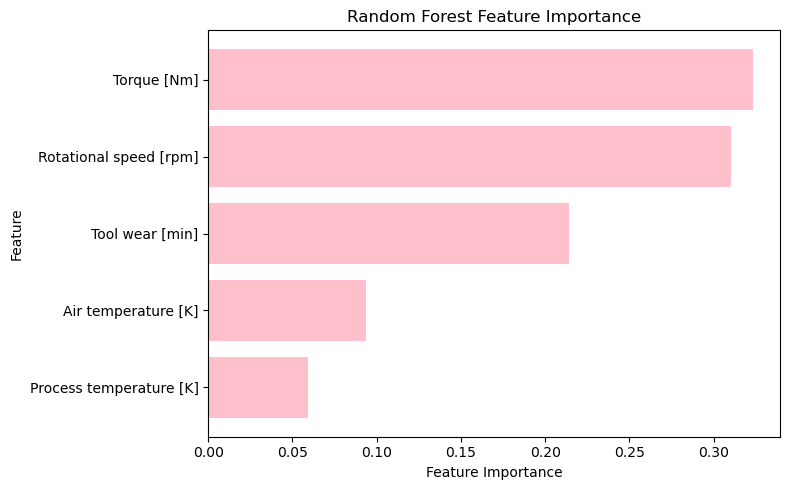

In [47]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color='pink')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../visuals/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()


The Random Forest feature importance results show which sensor measurements contributed most to the model's failure predictions. This helps make the model more interpretable by identifying which machine conditions were most useful for detecting failure risk.


## Model Comparison

To evaluate whether Random Forest was the best choice for this dataset, I compared it against simpler and alternative classification models. Since the dataset is highly imbalanced, I focused on recall, F1 score, and F2 score rather than accuracy alone.




### Model Comparison at Default Threshold

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
import pandas as pd

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
    ]),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        preds = (probs >= 0.50).astype(int)
    else:
        preds = model.predict(X_test)
    
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1 Score": f1_score(y_test, preds, zero_division=0),
        "F2 Score": fbeta_score(y_test, preds, beta=2, zero_division=0)
    })

model_comparison = pd.DataFrame(model_results)
model_comparison







,Model,Accuracy,Precision,Recall,F1 Score,F2 Score
0,Logistic Regression,0.8210,0.141089,0.838235,0.241525,0.421598
1,Random Forest,0.9830,0.886364,0.573529,0.696429,0.617089
2,Gradient Boosting,0.9845,0.877551,0.632353,0.735043,0.669782


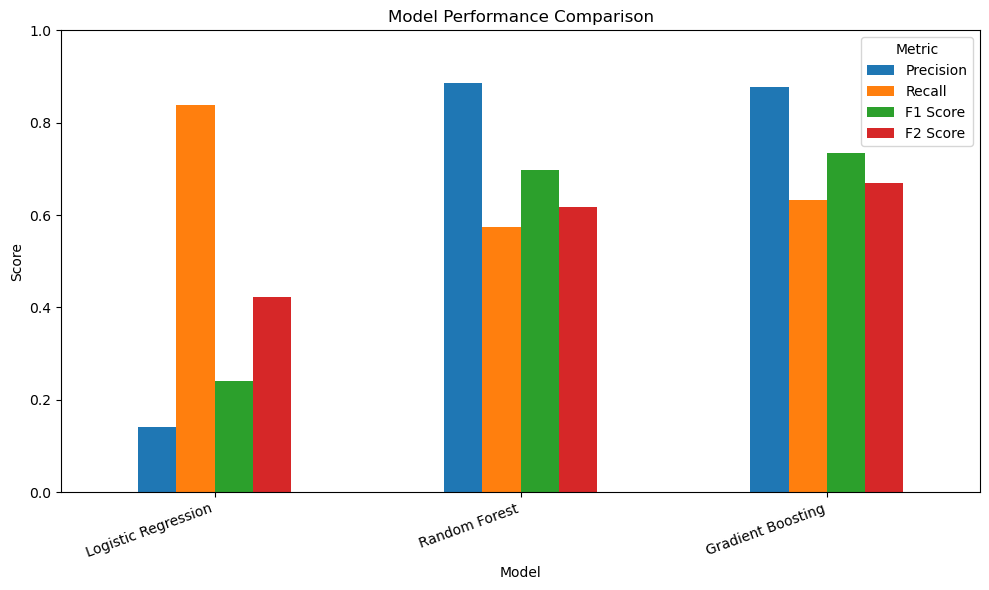

In [49]:
metrics_to_plot = ["Precision", "Recall", "F1 Score", "F2 Score"]

model_comparison.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig("../visuals/model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

Gradient Boosting performed similarly to Random Forest across the main evaluation metrics. This suggests that both tree-based ensemble methods were able to capture similar patterns in the sensor data. Since the dataset is highly imbalanced, the most important comparison was failure class recall and F2 score rather than accuracy alone.



### Model Comparison with F2-Optimized Thresholds





In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, accuracy_score
import numpy as np
import pandas as pd

def find_best_threshold(model, X_test, y_test):
    probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.01, 1.00, 0.01)
    
    results = []

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        
        results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds, zero_division=0),
            "recall": recall_score(y_test, preds, zero_division=0),
            "f1": f1_score(y_test, preds, zero_division=0),
            "f2": fbeta_score(y_test, preds, beta=2, zero_division=0)
        })

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df["f2"].idxmax()]
    
    return best_row, results_df
    

In [68]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Random Forest
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
rf_best_row, rf_threshold_results = find_best_threshold(rf, X_test, y_test)

# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)
gb_best_row, gb_threshold_results = find_best_threshold(gb, X_test, y_test)

# Logistic Regression
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])
log_reg.fit(X_train, y_train)
log_reg_best_row, log_reg_threshold_results = find_best_threshold(log_reg, X_test, y_test)

# Final comparison table
optimized_model_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", **log_reg_best_row.to_dict()},
    {"Model": "Random Forest", **rf_best_row.to_dict()},
    {"Model": "Gradient Boosting", **gb_best_row.to_dict()}
])

optimized_model_comparison

,Model,threshold,accuracy,precision,recall,f1,f2
0,Logistic Regression,0.75,0.9335,0.290323,0.661765,0.403587,0.526932
1,Random Forest,0.33,0.9865,0.836066,0.750000,0.790698,0.765766
2,Gradient Boosting,0.23,0.9825,0.720000,0.794118,0.755245,0.778098


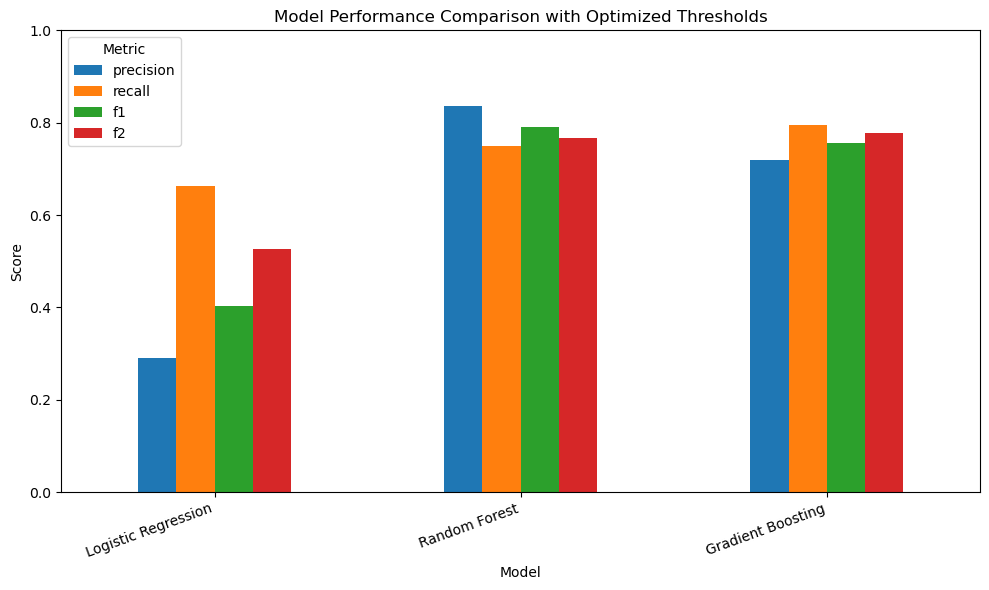

In [70]:
import matplotlib.pyplot as plt
import os

os.makedirs("../visuals", exist_ok=True)

metrics_to_plot = ["precision", "recall", "f1", "f2"]

optimized_model_comparison.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison with Optimized Thresholds")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig("../visuals/optimized_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Final Model Selection

After comparing models at both the default threshold and F2-optimized thresholds, the tree-based ensemble models performed similarly. Since the goal of predictive maintenance is to catch as many failures as possible while keeping false alarms reasonable, I used F2 score as the main selection metric.

Random Forest was selected as the final model because it achieved strong recall and F2 performance while also providing feature importance values that make the model easier to interpret.

## Decision Tree Visualization

To make the model logic more interpretable, I trained a shallow decision tree with a maximum depth of 3. This simplified tree shows how sensor features such as torque, tool wear, and rotational speed can be used to split machines into higher- and lower-risk groups. The simplified tree is mainly used for visualization, while the Random Forest remains the stronger predictive model because it combines many trees instead of relying on a single decision path.

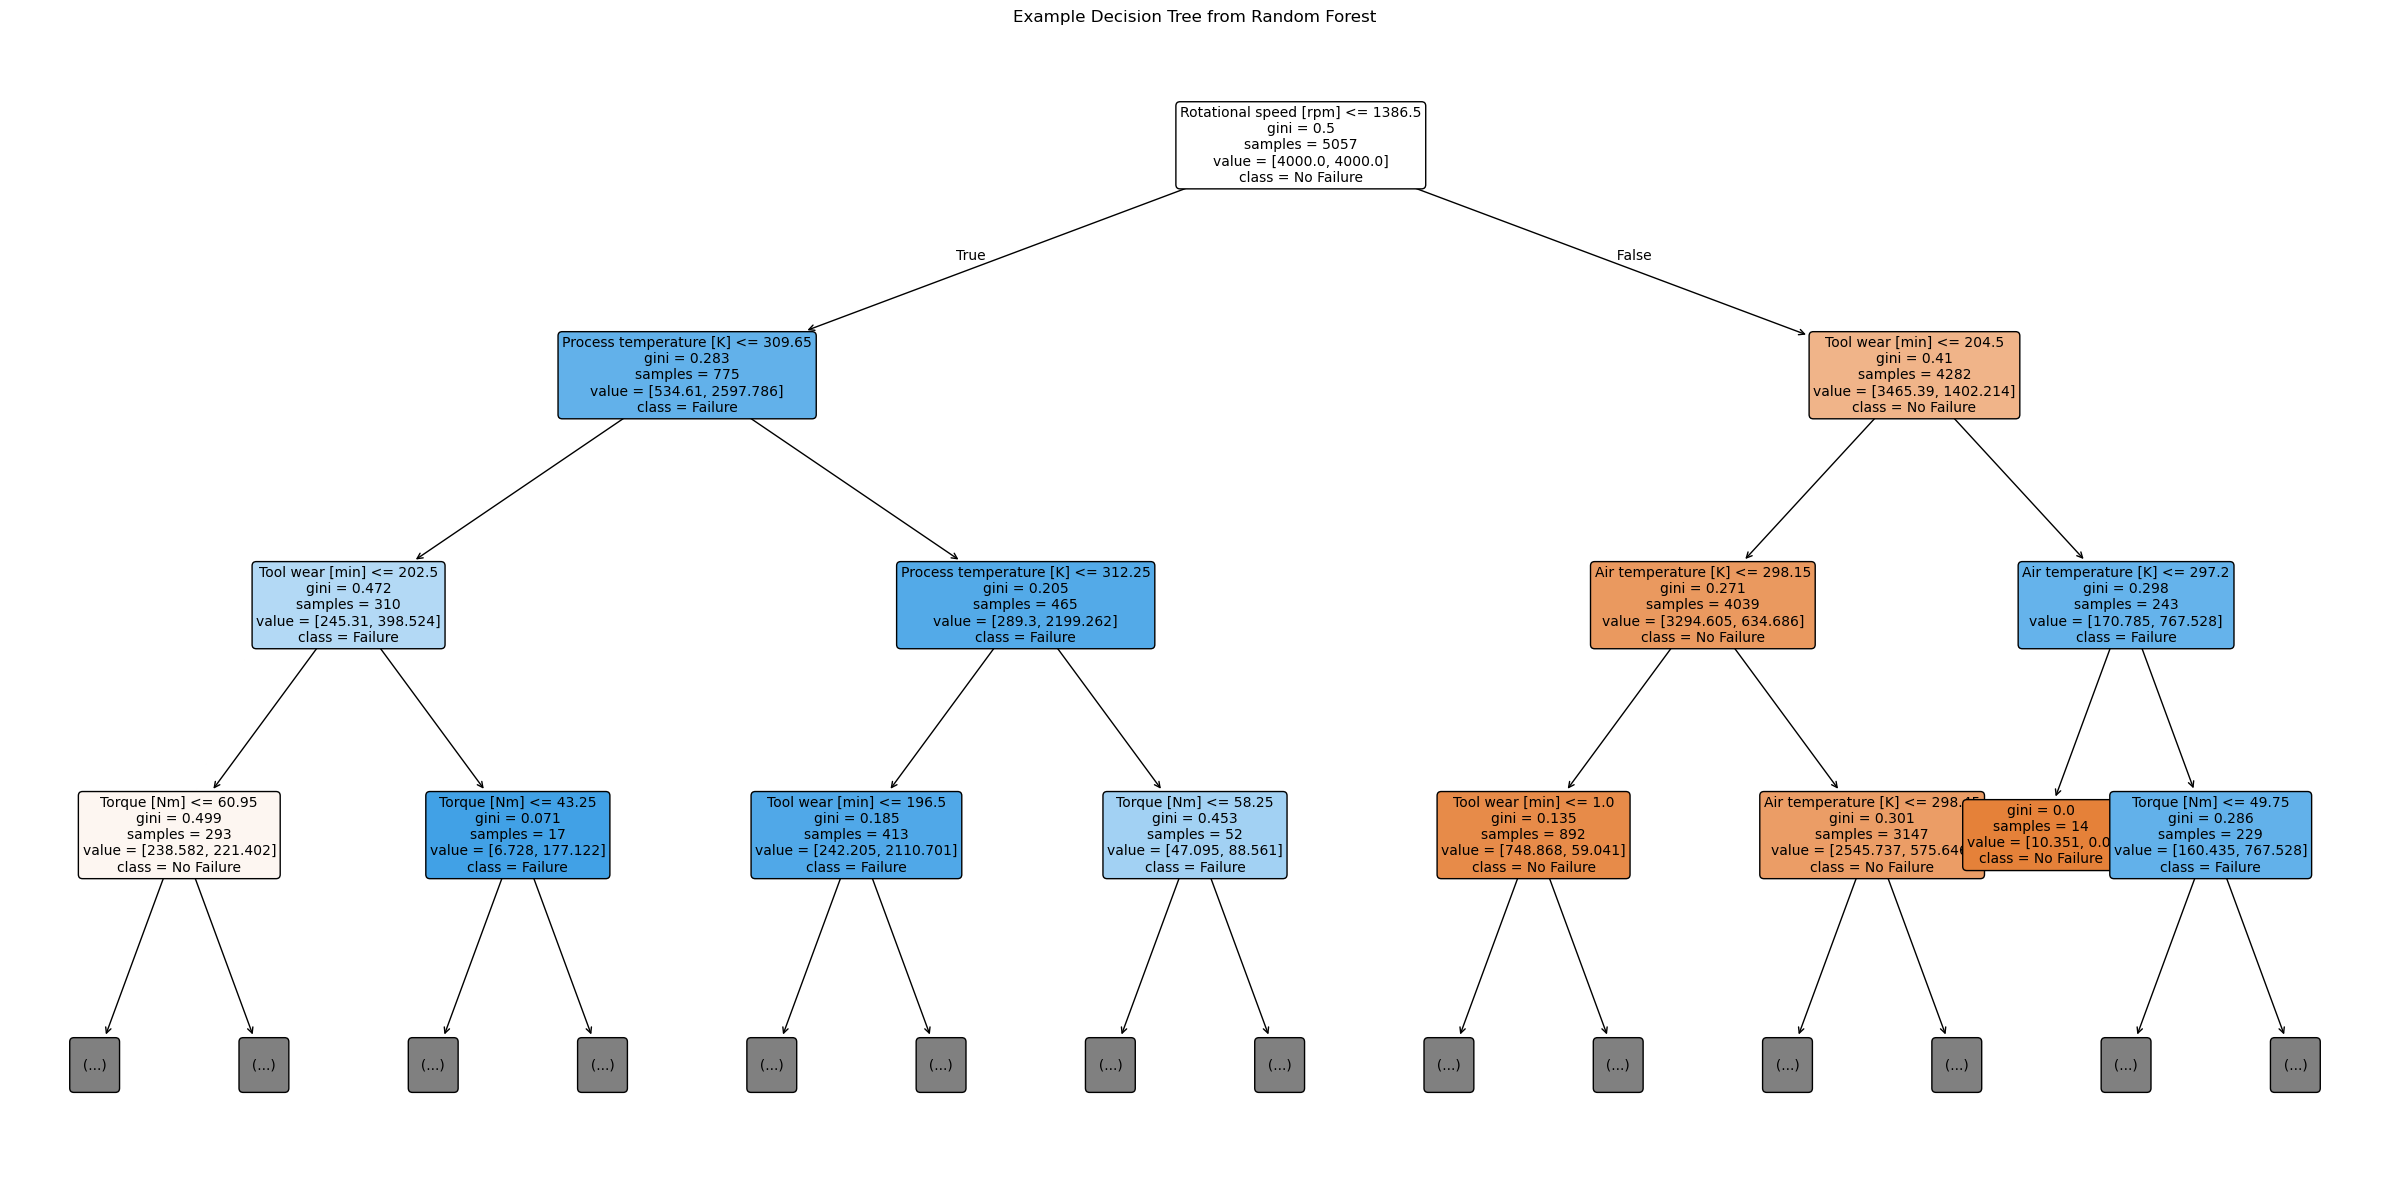

In [71]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os

os.makedirs("../visuals", exist_ok=True)

single_tree = rf.estimators_[0]

plt.figure(figsize=(24, 12))

plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["No Failure", "Failure"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Example Decision Tree from Random Forest")
plt.tight_layout()
plt.savefig("../visuals/random_forest_example_tree.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

This project built and evaluated machine learning models for predicting machine failure using industrial sensor data. Because the dataset was highly imbalanced, with only 3.39% of samples representing failures, accuracy alone was not a reliable metric. Instead, recall and F2 score were emphasized because missed failures are more costly in predictive maintenance.

Tree-based ensemble models, including Random Forest and Gradient Boosting, performed similarly after threshold optimization. The final model selection prioritized failure detection performance while also considering interpretability. Random Forest was useful because it provided strong predictive performance and feature importance values that helped identify which sensor readings contributed most to failure predictions.

Overall, threshold optimization improved the model's ability to detect machine failures compared to the default 0.50 threshold, showing that classification threshold choice is an important design decision for imbalanced predictive maintenance problems.